In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("loan_data.csv")

In [3]:
num_buckets = 5

df["fico_bucket"] = pd.qcut(
    df["fico_score"],
    q=num_buckets,
    labels=False
)

In [4]:
bucket_summary = df.groupby("fico_bucket").agg({
    "fico_score": ["min", "max"],
    "default": "mean"
})

bucket_summary.columns = [
    "Min FICO",
    "Max FICO",
    "PD"
]

# Sort by PD
bucket_summary = bucket_summary.sort_values("PD")

# Assign ratings
bucket_summary["Rating"] = range(
    1,
    len(bucket_summary)+1
)

print(bucket_summary)

             Min FICO  Max FICO        PD  Rating
fico_bucket                                      
4                 689       850  0.054190       1
3                 654       688  0.100150       2
2                 624       653  0.151332       3
1                 588       623  0.215627       4
0                 408       587  0.398537       5


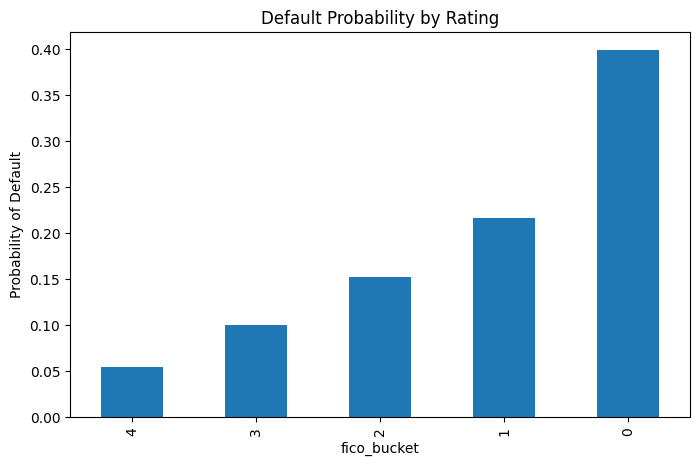

In [5]:
bucket_summary["PD"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Default Probability by Rating")

plt.ylabel("Probability of Default")

plt.show()

In [6]:
def get_rating(fico_score):
    
    for idx, row in bucket_summary.iterrows():
        
        if (
            fico_score >= row["Min FICO"]
            and
            fico_score <= row["Max FICO"]
        ):
            
            return {
                "FICO Score": fico_score,
                "Rating": int(row["Rating"]),
                "Probability of Default":
                round(row["PD"], 4)
            }

In [7]:
result = get_rating(720)

print(result)

{'FICO Score': 720, 'Rating': 1, 'Probability of Default': np.float64(0.0542)}
